![Banner](banner.jpg)

# Laboratorio 7: Perceptrón Multicapa usando Tensorflow/Keras

## 1. Introducción

En este laboratorio vamos a explorar cómo construir un **Perceptrón Multicapa (MLP)** utilizando **TensorFlow/Keras** para resolver una de las tareas clásicas del aprendizaje automático: la **identificación de dígitos escritos a mano**.

El dataset que utilizaremos es MNIST, que se ha convertido en el estándar por excelencia para enseñar y evaluar modelos de clasificación de imágenes. MNIST contiene **70,000 imágenes** de dígitos del 0 al 9, escritos a mano, en escala de grises, con una resolución de **28x28 píxeles**.

### ¿Qué es un Perceptrón Multicapa (MLP)?

Un MLP es un tipo de red neuronal artificial compuesta por **múltiples capas de neuronas** completamente conectadas:

- **Capa de entrada**: Recibe los datos (en nuestro caso, los 784 píxeles de cada imagen).
- **Capas ocultas**: Capas intermedias que aprenden representaciones cada vez más abstractas de los datos.
- **Capa de salida**: Produce la predicción final (en nuestro caso, las probabilidades de cada uno de los 10 dígitos).

Cada neurona aplica una **transformación lineal** seguida de una **función de activación no lineal** (como ReLU), lo que permite al modelo aprender relaciones complejas en los datos.

### Objetivos del laboratorio

1. Cargar y explorar el dataset MNIST.
2. Preprocesar las imágenes para que puedan ser utilizadas por una red neuronal.
3. Construir un MLP desde cero usando TensorFlow/Keras.
4. Entrenar el modelo y evaluar su desempeño.
5. Visualizar los resultados y las predicciones del modelo.

## 2. Preparación del entorno

### 2.1. Instalación de paquetes

Primero, instalemos las librerías necesarias para este laboratorio.

In [ ]:
!pip install tensorflow matplotlib numpy

### 2.2. Importación de librerías

In [24]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Verificar si hay GPU disponible
print(f'GPUs disponibles: {len(tf.config.list_physical_devices("GPU"))}')
print(f'Dispositivos: {[d.name for d in tf.config.list_physical_devices()]}')

GPUs disponibles: 1
Dispositivos: ['/physical_device:CPU:0', '/physical_device:GPU:0']


Versiones utilizadas de las librerías importadas:

In [2]:
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('NumPy:', np.__version__)

TensorFlow: 2.21.0
Keras: 3.13.2
NumPy: 2.3.5


## 3. Carga y exploración del dataset MNIST

El dataset MNIST se puede descargar directamente mediante `keras.datasets`. Este dataset ya viene dividido en un conjunto de **entrenamiento** (60,000 imágenes) y un conjunto de **prueba** (10,000 imágenes).

Para preparar los datos, aplicaremos dos transformaciones:
1. **Normalización**: Dividimos los valores de los píxeles entre 255 para que queden en el rango [0, 1].
2. **Aplanamiento**: Convertimos cada imagen de 28×28 a un vector de 784 elementos para la entrada del MLP.

In [3]:
# Descargar y cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f'Tamaño del conjunto de entrenamiento: {len(x_train)}')
print(f'Tamaño del conjunto de prueba: {len(x_test)}')
print(f'Forma de una imagen: {x_train[0].shape}')
print(f'Rango de valores de píxeles: [{x_train.min()}, {x_train.max()}]')
print(f'Número de clases: {len(np.unique(y_train))}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Tamaño del conjunto de entrenamiento: 60000
Tamaño del conjunto de prueba: 10000
Forma de una imagen: (28, 28)
Rango de valores de píxeles: [0, 255]
Número de clases: 10


### 3.1. Visualización de ejemplos del dataset

Antes de construir nuestro modelo, es importante familiarizarnos con los datos. Visualicemos algunas de las imágenes del dataset junto con sus etiquetas correspondientes.

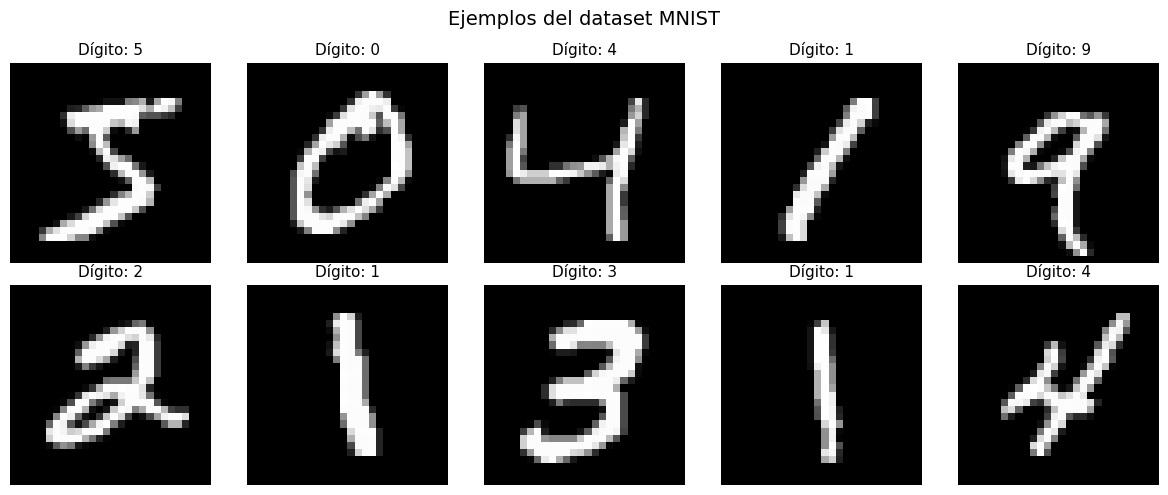

In [4]:
# Visualizar una cuadrícula de imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Ejemplos del dataset MNIST', fontsize=14)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Dígito: {y_train[i]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3.2. Exploración de la distribución de clases

Es buena práctica verificar que el dataset esté balanceado, es decir, que cada dígito tenga una cantidad similar de ejemplos.

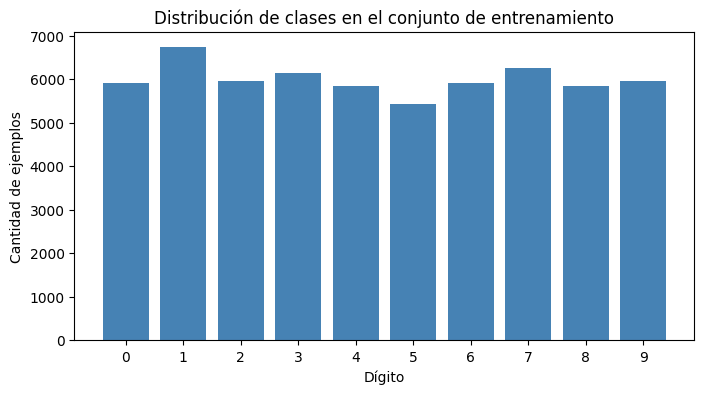

Dígito 0: 5923 ejemplos
Dígito 1: 6742 ejemplos
Dígito 2: 5958 ejemplos
Dígito 3: 6131 ejemplos
Dígito 4: 5842 ejemplos
Dígito 5: 5421 ejemplos
Dígito 6: 5918 ejemplos
Dígito 7: 6265 ejemplos
Dígito 8: 5851 ejemplos
Dígito 9: 5949 ejemplos


In [5]:
# Contar la cantidad de ejemplos por clase
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue')
plt.xlabel('Dígito')
plt.ylabel('Cantidad de ejemplos')
plt.title('Distribución de clases en el conjunto de entrenamiento')
plt.xticks(unique)
plt.show()

for digit, count in zip(unique, counts):
    print(f'Dígito {digit}: {count} ejemplos')

### 3.3. Preprocesamiento de los datos

Para entrenar nuestro modelo de forma eficiente, necesitamos:

1. **Normalizar** los valores de los píxeles al rango [0, 1].
2. **Aplanar** las imágenes de 28×28 a vectores de 784 elementos.

Adicionalmente, crearemos datasets de TensorFlow con lotes (batches), lo cual:
- Permite al modelo ver varios ejemplos al tiempo, proporcionando una señal de aprendizaje más estable.
- Mejora la eficiencia computacional al aprovechar el paralelismo.
- Facilita el uso de gradiente descendiente estocástico (SGD) por mini-lotes.

In [6]:
# Normalizar los valores de los píxeles al rango [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Aplanar las imágenes de 28x28 a vectores de 784
x_train_flat = x_train_norm.reshape(-1, 28 * 28)
x_test_flat = x_test_norm.reshape(-1, 28 * 28)

print(f'Forma de los datos de entrenamiento: {x_train_flat.shape}')
print(f'Forma de los datos de prueba: {x_test_flat.shape}')
print(f'Rango de valores normalizado: [{x_train_flat.min():.1f}, {x_train_flat.max():.1f}]')

Forma de los datos de entrenamiento: (60000, 784)
Forma de los datos de prueba: (10000, 784)
Rango de valores normalizado: [0.0, 1.0]


In [7]:
# Tamaño del lote
batch_size = 64

# Crear datasets de TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train)).shuffle(60000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test)).batch(batch_size)

# Verificar la forma de un lote
for images, labels in train_dataset.take(1):
    print(f'Forma del lote de imágenes: {images.shape}')
    print(f'Forma del lote de etiquetas: {labels.shape}')
    print(f'Esto significa que tenemos {images.shape[0]} vectores de {images.shape[1]} elementos (píxeles)')

Forma del lote de imágenes: (64, 784)
Forma del lote de etiquetas: (64,)
Esto significa que tenemos 64 vectores de 784 elementos (píxeles)


I0000 00:00:1774809168.214454   10191 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


## 4. Construcción del modelo MLP

Ahora que tenemos los datos listos, vamos a construir nuestro Perceptrón Multicapa. La arquitectura de nuestro modelo será la siguiente:

1. **Capa de entrada**: 784 neuronas (28 × 28 píxeles aplanados).
2. **Primera capa oculta**: 256 neuronas con activación ReLU.
3. **Segunda capa oculta**: 128 neuronas con activación ReLU.
4. **Capa de salida**: 10 neuronas (una por cada dígito del 0 al 9).

Recordemos que cada neurona aplica la operación: $\mathbf{y} = f(\mathbf{W} \cdot \mathbf{x} + \mathbf{b})$

Donde $\mathbf{W}$ son los pesos, $\mathbf{b}$ es el sesgo, y $f$ es la función de activación.

### 4.1. Implementación manual (desde cero)

Primero, implementemos el MLP de forma manual para comprender cómo funcionan las capas por dentro. Definiremos los pesos y sesgos como variables de TensorFlow con seguimiento de gradientes mediante `tf.GradientTape`, el mecanismo de autodiferenciación de TensorFlow.

In [8]:
# Dimensiones del modelo
input_size = 28 * 28   # 784 píxeles
hidden1_size = 256     # Primera capa oculta
hidden2_size = 128     # Segunda capa oculta
output_size = 10       # 10 dígitos (0-9)

# Parámetros de la primera capa oculta
W1 = tf.Variable(tf.random.normal([input_size, hidden1_size], stddev=0.01))
b1 = tf.Variable(tf.zeros([hidden1_size]))

# Parámetros de la segunda capa oculta
W2 = tf.Variable(tf.random.normal([hidden1_size, hidden2_size], stddev=0.01))
b2 = tf.Variable(tf.zeros([hidden2_size]))

# Parámetros de la capa de salida
W3 = tf.Variable(tf.random.normal([hidden2_size, output_size], stddev=0.01))
b3 = tf.Variable(tf.zeros([output_size]))

parameters = [W1, b1, W2, b2, W3, b3]
total_params = sum(p.numpy().size for p in parameters)
print(f'Número total de parámetros: {total_params:,}')
print(f'  - Capa 1: W1 {W1.shape}, b1 {b1.shape} = {W1.numpy().size + b1.numpy().size:,} parámetros')
print(f'  - Capa 2: W2 {W2.shape}, b2 {b2.shape} = {W2.numpy().size + b2.numpy().size:,} parámetros')
print(f'  - Capa 3: W3 {W3.shape}, b3 {b3.shape} = {W3.numpy().size + b3.numpy().size:,} parámetros')

Número total de parámetros: 235,146
  - Capa 1: W1 (784, 256), b1 (256,) = 200,960 parámetros
  - Capa 2: W2 (256, 128), b2 (128,) = 32,896 parámetros
  - Capa 3: W3 (128, 10), b3 (10,) = 1,290 parámetros


In [9]:
def mlp_manual(x):
    """MLP implementado manualmente."""
    # Primera capa oculta: transformación lineal + ReLU
    h1 = tf.nn.relu(tf.matmul(x, W1) + b1)

    # Segunda capa oculta: transformación lineal + ReLU
    h2 = tf.nn.relu(tf.matmul(h1, W2) + b2)

    # Capa de salida: transformación lineal (sin activación, ya que usaremos SparseCategoricalCrossentropy)
    logits = tf.matmul(h2, W3) + b3

    return logits

# Verificar que el modelo funcione correctamente
for sample_batch, _ in train_dataset.take(1):
    output = mlp_manual(sample_batch)
    print(f'Forma de la entrada: {sample_batch.shape}')
    print(f'Forma de la salida: {output.shape}')
    print(f'\nLos logits para la primera imagen del lote son:')
    print(output[0].numpy())

Forma de la entrada: (64, 784)
Forma de la salida: (64, 10)

Los logits para la primera imagen del lote son:
[-0.00031495 -0.00086672  0.00107604 -0.00092264 -0.00084514  0.00054544
  0.00167083  0.00014322 -0.00018253 -0.00057953]


### 4.2. Entrenamiento del modelo manual

Vamos a entrenar nuestro modelo manual utilizando:
- **Función de pérdida**: `SparseCategoricalCrossentropy(from_logits=True)`, que aplica internamente softmax y calcula la entropía cruzada. Es la función estándar para problemas de clasificación multiclase.
- **Optimizador**: Gradiente descendiente estocástico (SGD) con una tasa de aprendizaje fija.
- **GradientTape**: El mecanismo de TensorFlow para calcular gradientes de forma automática.

In [10]:
lr = 0.01  # Tasa de aprendizaje
epochs = 5 # Número de épocas

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    num_batches = 0

    for batch_images, batch_labels in train_dataset:
        # GradientTape registra las operaciones para calcular gradientes
        with tf.GradientTape() as tape:
            # Forward: calcular las predicciones
            logits = mlp_manual(batch_images)

            # Calcular la pérdida (Cross Entropy Loss)
            loss = loss_fn(batch_labels, logits)

        # Backward: calcular los gradientes
        grads = tape.gradient(loss, parameters)

        # Actualizar los parámetros manualmente (SGD)
        for param, grad in zip(parameters, grads):
            param.assign_sub(lr * grad)

        # Registrar métricas
        epoch_loss += loss.numpy()
        predicted = tf.argmax(logits, axis=1, output_type=tf.int32)
        correct += tf.reduce_sum(tf.cast(predicted == tf.cast(batch_labels, tf.int32), tf.int32)).numpy()
        total += batch_labels.shape[0]
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    accuracy = correct / total
    losses.append(avg_loss)
    print(f'Época {epoch+1}/{epochs} - Pérdida: {avg_loss:.4f} - Precisión: {accuracy:.4f}')

Época 1/5 - Pérdida: 2.3005 - Precisión: 0.1128
Época 2/5 - Pérdida: 2.2880 - Precisión: 0.1329
Época 3/5 - Pérdida: 1.8422 - Precisión: 0.4678
Época 4/5 - Pérdida: 0.8236 - Precisión: 0.7373
Época 5/5 - Pérdida: 0.6313 - Precisión: 0.8061


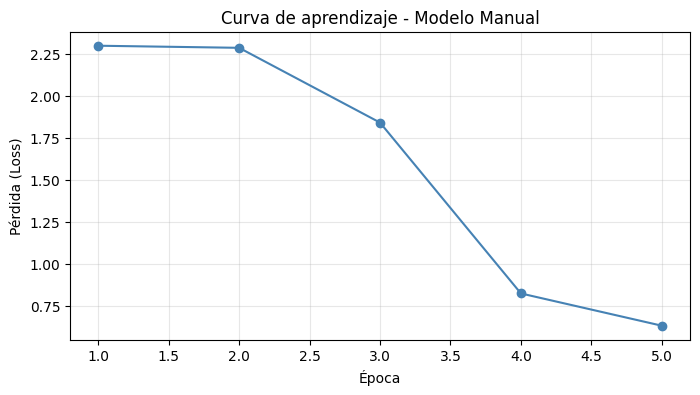

In [11]:
# Visualizar la curva de pérdida durante el entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), losses, marker='o', color='steelblue')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.title('Curva de aprendizaje - Modelo Manual')
plt.grid(True, alpha=0.3)
plt.show()

### 4.3. Evaluación del modelo manual en el conjunto de prueba

Evaluemos el desempeño de nuestro modelo sobre datos que nunca ha visto (el conjunto de prueba).

In [12]:
def evaluate_manual(model_fn, data_loader):
    """Evalúa un modelo en un conjunto de datos."""
    correct = 0
    total = 0

    for images, labels in data_loader:
        logits = model_fn(images)
        predicted = tf.argmax(logits, axis=1, output_type=tf.int32)
        correct += tf.reduce_sum(tf.cast(predicted == tf.cast(labels, tf.int32), tf.int32)).numpy()
        total += labels.shape[0]

    accuracy = correct / total
    return accuracy

accuracy = evaluate_manual(mlp_manual, test_dataset)
print(f'Precisión del modelo manual en el conjunto de prueba: {accuracy:.4f} ({accuracy*100:.2f}%)')

Precisión del modelo manual en el conjunto de prueba: 0.8298 (82.98%)


## 5. Implementación con la API de Keras

Ahora que hemos comprendido cómo funciona un MLP por dentro, vamos a utilizar las herramientas de alto nivel de **Keras** para construir el mismo modelo de una forma más elegante y mantenible.

La API `Sequential` de Keras nos permite definir modelos apilando capas de forma sencilla, encapsulando los parámetros y la lógica del modelo automáticamente.

In [13]:
# Construir el modelo MLP con la API Sequential de Keras
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,), name='capa_oculta_1'),
    layers.Dense(128, activation='relu', name='capa_oculta_2'),
    layers.Dense(10, name='capa_salida')
], name='MLP_MNIST')

# Ver el resumen del modelo
model.summary()

/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### 5.1. Compilación del modelo

Para entrenar nuestro modelo, necesitamos compilarlo definiendo:
- **Función de pérdida**: `SparseCategoricalCrossentropy(from_logits=True)`, que internamente aplica softmax a los logits y calcula la entropía cruzada con las etiquetas reales.
- **Optimizador**: Usaremos **Adam**, un optimizador más avanzado que SGD, que adapta la tasa de aprendizaje de cada parámetro de forma individual.
- **Métrica**: `accuracy` para monitorear la precisión durante el entrenamiento.

In [14]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### 5.2. Entrenamiento del modelo

Ahora, entrenemos nuestro modelo por varias épocas. Keras se encarga automáticamente de registrar las métricas de entrenamiento y validación.

In [15]:
epochs = 10

print('Entrenamiento del modelo MLP con Keras')
print('=' * 60)

history = model.fit(
    x_train_flat, y_train,
    batch_size=64,
    epochs=epochs,
    validation_data=(x_test_flat, y_test),
    verbose=1
)

print('=' * 60)
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f'Precisión final en test: {test_acc*100:.2f}%')

Entrenamiento del modelo MLP con Keras
Epoch 1/10


I0000 00:00:1774810158.398934   12521 service.cc:153] XLA service 0x7f8e1c044a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774810158.398962   12521 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774810158.451742   12521 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774810158.562614   12521 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774810158.573332   12521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_469270__.11
I0000 00:00:1774810159.520032   12521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 55/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6237 - loss: 1.3628

I0000 00:00:1774810161.245945   12521 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8834 - loss: 0.4099

I0000 00:00:1774810163.537309   12518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_469270__.11
I0000 00:00:1774810163.645311   12518 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9331 - loss: 0.2279 - val_accuracy: 0.9642 - val_loss: 0.1088
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9717 - loss: 0.0906 - val_accuracy: 0.9723 - val_loss: 0.0884
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9809 - loss: 0.0617 - val_accuracy: 0.9722 - val_loss: 0.0855
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9862 - loss: 0.0433 - val_accuracy: 0.9797 - val_loss: 0.0691
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9890 - loss: 0.0339 - val_accuracy: 0.9775 - val_loss: 0.0763
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9770 - val_loss: 0.0775
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9926 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0871
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9936 - loss: 0.0194 - val_accuracy: 0.9785 - val_

### 5.3. Visualización de las métricas de entrenamiento

Visualicemos las curvas de pérdida y precisión durante el entrenamiento para verificar que el modelo esté aprendiendo correctamente.

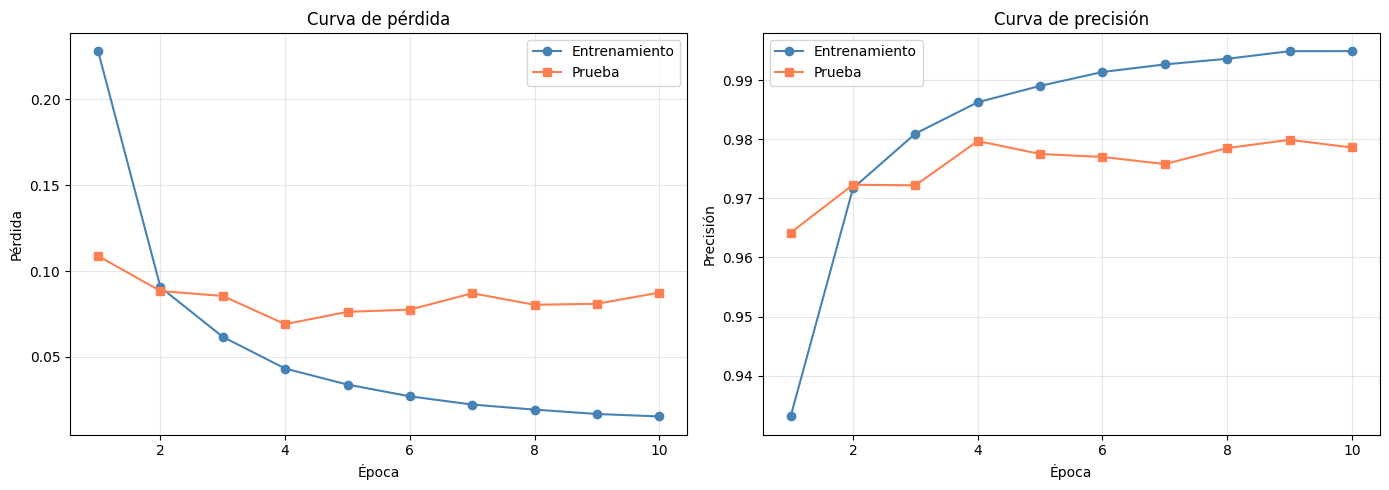

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
ax1.plot(range(1, epochs + 1), history.history['loss'], marker='o', label='Entrenamiento', color='steelblue')
ax1.plot(range(1, epochs + 1), history.history['val_loss'], marker='s', label='Prueba', color='coral')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.set_title('Curva de pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curva de precisión
ax2.plot(range(1, epochs + 1), history.history['accuracy'], marker='o', label='Entrenamiento', color='steelblue')
ax2.plot(range(1, epochs + 1), history.history['val_accuracy'], marker='s', label='Prueba', color='coral')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva de precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis de resultados

### 6.1. Visualización de predicciones

Veamos algunas predicciones del modelo sobre imágenes del conjunto de prueba. Mostraremos tanto las predicciones correctas como las incorrectas.

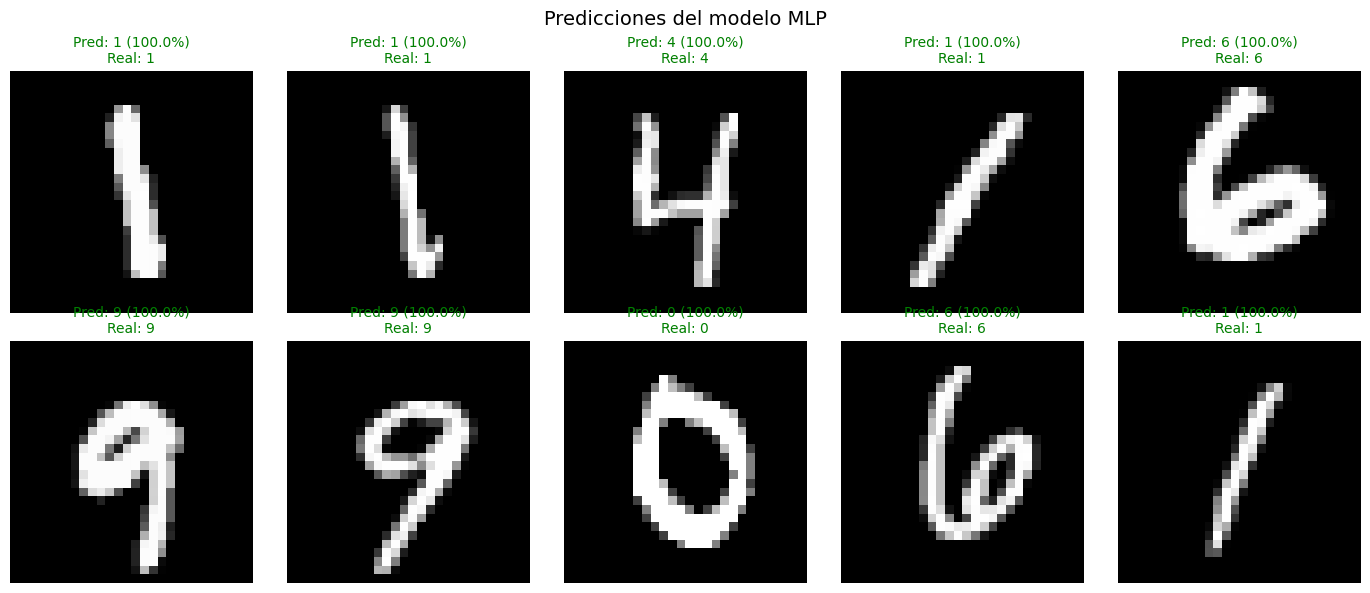

In [17]:
def show_predictions(model, x_data, y_data, x_images, num_images=10):
    """Muestra predicciones del modelo sobre imágenes aleatorias."""
    indices = np.random.choice(len(x_data), num_images, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle('Predicciones del modelo MLP', fontsize=14)

    for i, ax in enumerate(axes.flatten()):
        idx = indices[i]
        image_flat = x_data[idx:idx+1]
        true_label = y_data[idx]

        logits = model(image_flat, training=False)
        probs = tf.nn.softmax(logits).numpy()[0]
        pred_label = np.argmax(probs)
        confidence = probs[pred_label]

        ax.imshow(x_images[idx], cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'Pred: {pred_label} ({confidence:.1%})\nReal: {true_label}',
                     color=color, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, x_test_flat, y_test, x_test)

### 6.2. Matriz de confusión

La matriz de confusión nos permite observar qué dígitos son más difíciles de clasificar para el modelo, y con cuáles dígitos tiende a confundirlos.

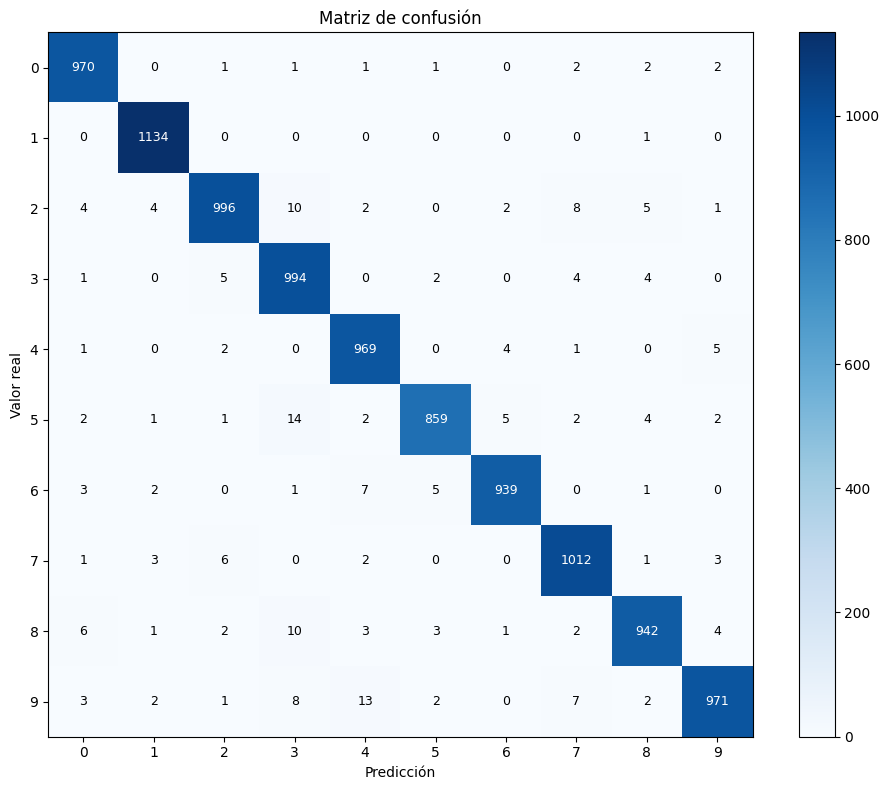

In [18]:
def compute_confusion_matrix(model, x_data, y_data, num_classes=10):
    """Calcula la matriz de confusión."""
    logits = model(x_data, training=False)
    predicted = tf.argmax(logits, axis=1).numpy()
    confusion = tf.math.confusion_matrix(y_data, predicted, num_classes=num_classes).numpy()
    return confusion

confusion = compute_confusion_matrix(model, x_test_flat, y_test)

plt.figure(figsize=(10, 8))
plt.imshow(confusion, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.xticks(range(10))
plt.yticks(range(10))

# Agregar los valores numéricos dentro de cada celda
for i in range(10):
    for j in range(10):
        color = 'white' if confusion[i, j] > confusion.max() / 2 else 'black'
        plt.text(j, i, str(confusion[i, j]),
                 ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.show()

### 6.3. Precisión por dígito

Podemos observar qué dígitos son más fáciles y cuáles más difíciles de clasificar para nuestro modelo.

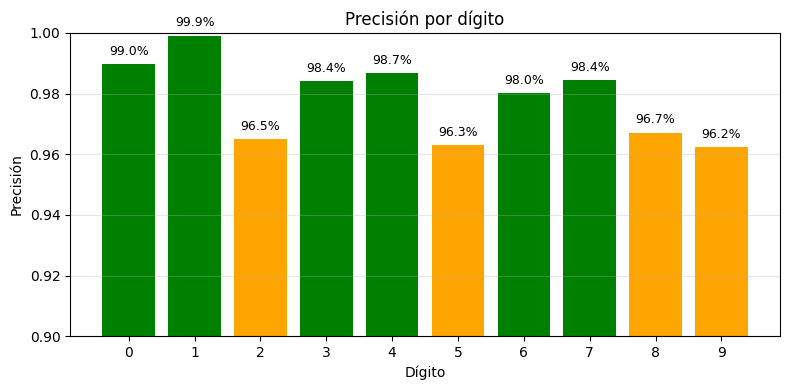

In [19]:
# Calcular la precisión por dígito
per_class_accuracy = np.diag(confusion).astype(float) / confusion.sum(axis=1).astype(float)

plt.figure(figsize=(8, 4))
colors = ['green' if acc > 0.97 else 'orange' if acc > 0.95 else 'red' for acc in per_class_accuracy]
plt.bar(range(10), per_class_accuracy, color=colors)
plt.xlabel('Dígito')
plt.ylabel('Precisión')
plt.title('Precisión por dígito')
plt.xticks(range(10))
plt.ylim(0.9, 1.0)
plt.grid(True, alpha=0.3, axis='y')

for i, acc in enumerate(per_class_accuracy):
    plt.text(i, acc + 0.002, f'{acc:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Experimentación: Efecto de la arquitectura

Una parte importante del aprendizaje profundo es experimentar con diferentes arquitecturas y observar cómo afectan el desempeño del modelo. Comparemos diferentes configuraciones del MLP.

In [25]:
# Definir diferentes arquitecturas para comparar
architectures = {
    'Pequeño (64)': [64],
    'Mediano (256, 128)': [256, 128],
    'Grande (512, 256, 128)': [512, 256, 128],
}

def build_flexible_mlp(hidden_sizes, input_size=784, output_size=10):
    """Construye un MLP con número variable de capas ocultas."""
    model_layers = []
    for i, h_size in enumerate(hidden_sizes):
        if i == 0:
            model_layers.append(layers.Dense(h_size, activation='relu', input_shape=(input_size,)))
        else:
            model_layers.append(layers.Dense(h_size, activation='relu'))
    model_layers.append(layers.Dense(output_size))
    return keras.Sequential(model_layers)

results = {}

for name, hidden_sizes in architectures.items():
    print(f'\nEntrenando arquitectura: {name}')
    m = build_flexible_mlp(hidden_sizes)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    n_params = m.count_params()
    print(f'  Parámetros: {n_params:,}')

    hist = m.fit(x_train_flat, y_train, batch_size=64, epochs=5,
                 validation_data=(x_test_flat, y_test), verbose=0)

    best_acc = max(hist.history['val_accuracy'])
    for epoch_i in range(5):
        print(f'  Época {epoch_i+1}/5 - Precisión test: {hist.history["val_accuracy"][epoch_i]:.4f}')

    results[name] = {'accuracy': best_acc, 'params': n_params}

print('\n' + '=' * 50)
print('Resumen de resultados:')
print('=' * 50)
for name, res in results.items():
    print(f'{name:30s} | Precisión: {res["accuracy"]*100:.2f}% | Parámetros: {res["params"]:>10,}')


Entrenando arquitectura: Pequeño (64)
  Parámetros: 50,890


I0000 00:00:1774810805.573049   12518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_656963__.10
I0000 00:00:1774810807.990809   12520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_656963__.10


  Época 1/5 - Precisión test: 0.9419
  Época 2/5 - Precisión test: 0.9568
  Época 3/5 - Precisión test: 0.9653
  Época 4/5 - Precisión test: 0.9677
  Época 5/5 - Precisión test: 0.9705

Entrenando arquitectura: Mediano (256, 128)
  Parámetros: 235,146


I0000 00:00:1774810820.808495   12520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_680436__.11
I0000 00:00:1774810823.798541   12518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_680436__.11


  Época 1/5 - Precisión test: 0.9668
  Época 2/5 - Precisión test: 0.9714
  Época 3/5 - Precisión test: 0.9743
  Época 4/5 - Precisión test: 0.9757
  Época 5/5 - Precisión test: 0.9762

Entrenando arquitectura: Grande (512, 256, 128)
  Parámetros: 567,434


I0000 00:00:1774810841.238141   12519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_704228__.12
I0000 00:00:1774810844.422517   12518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_704228__.12


  Época 1/5 - Precisión test: 0.9698
  Época 2/5 - Precisión test: 0.9716
  Época 3/5 - Precisión test: 0.9768
  Época 4/5 - Precisión test: 0.9784
  Época 5/5 - Precisión test: 0.9770

Resumen de resultados:
Pequeño (64)                   | Precisión: 97.05% | Parámetros:     50,890
Mediano (256, 128)             | Precisión: 97.62% | Parámetros:    235,146
Grande (512, 256, 128)         | Precisión: 97.84% | Parámetros:    567,434


## 8. Conclusiones

En este laboratorio hemos explorado cómo construir un **Perceptrón Multicapa (MLP)** utilizando TensorFlow/Keras para la tarea de **identificación de dígitos manuscritos** con el dataset MNIST. A continuación, resumimos los principales aprendizajes:

1. **El MLP es capaz de alcanzar un alto desempeño** (~97-98%) en la tarea de clasificación de dígitos, lo que demuestra la capacidad de las redes neuronales para aprender patrones complejos en los datos.

2. **La implementación manual vs. Keras API**: Implementar el modelo desde cero con `tf.Variable` y `tf.GradientTape` nos ayuda a comprender los mecanismos internos (pesos, sesgos, gradientes), mientras que la API de Keras nos proporciona una interfaz limpia y eficiente para trabajar en proyectos más complejos.

3. **El preprocesamiento es fundamental**: La normalización de los datos y la correcta estructuración en batches son pasos esenciales para el entrenamiento eficiente del modelo.

5. **Limitaciones del MLP**: A pesar de los buenos resultados, los MLPs tienen limitaciones para el procesamiento de imágenes, ya que no consideran la estructura espacial de los píxeles. Para tareas más avanzadas de visión por computadora, se utilizan **Redes Neuronales Convolucionales (CNNs)**, que aprenden a detectar patrones locales como bordes y texturas.